# Peak tourism months exploration

Scatterplot of `data/processed/PEAK_TOURISM_INDICATOR_BY_COUNTRY.csv`
(see `data/scripts/compute_peak_tourism_indicator.py`) -- every
(country, month) row in the table, not just each country's single peak
month. Countries on the Y axis, alphabetical top-to-bottom; calendar
month (1-12) on the X axis. Marker color + size encode `PEAK_RATIO` (how
busy that month is relative to the country's own peak, 0-1), and each
country's actual peak month (`PEAK_RATIO == 1.0`) is outlined in red so
the peak-season pattern is easy to read at a glance.

Run `data/scripts/compute_peak_tourism_indicator.py` first if
`PEAK_TOURISM_INDICATOR_BY_COUNTRY.csv` doesn't exist yet or is stale.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Notebook lives in notebooks/, data lives in ../data/
DATA_DIR = Path("..") / "data" / "processed"
PEAK_TOURISM_PATH = DATA_DIR / "PEAK_TOURISM_INDICATOR_BY_COUNTRY.csv"

peak_tourism = pd.read_csv(PEAK_TOURISM_PATH)
peak_tourism.head()

,COUNTRY,MONTH,PEAK_RATIO,COUNTRY_NAME,SOURCE_YEAR,PASSENGERS
0,AT,1,0.6193,Austria,2026,2317970.0
1,AT,2,0.6266,Austria,2026,2345124.0
2,AT,3,0.7109,Austria,2026,2660638.0
3,AT,4,0.7461,Austria,2026,2792404.0
4,AT,5,0.8315,Austria,2025,3111959.0


## Sort countries alphabetically for the Y axis

In [5]:
# Alphabetical A->Z top-to-bottom. Matplotlib's categorical y-axis plots
# position 0 at the BOTTOM, so the list is reversed before assigning
# positions -- position 0 becomes the alphabetically-last country (bottom
# of the chart), and the highest position becomes the alphabetically-first
# country (top of the chart).
countries_top_to_bottom = sorted(peak_tourism["COUNTRY_NAME"].unique())
countries_bottom_to_top = list(reversed(countries_top_to_bottom))
country_to_y = {country: i for i, country in enumerate(countries_bottom_to_top)}

peak_tourism["y"] = peak_tourism["COUNTRY_NAME"].map(country_to_y)
peak_tourism[["COUNTRY_NAME", "MONTH", "PEAK_RATIO", "y"]].head()

,COUNTRY_NAME,MONTH,PEAK_RATIO,y
0,Austria,1,0.6193,37
1,Austria,2,0.6266,37
2,Austria,3,0.7109,37
3,Austria,4,0.7461,37
4,Austria,5,0.8315,37


## Scatterplot: every (country, month) observation

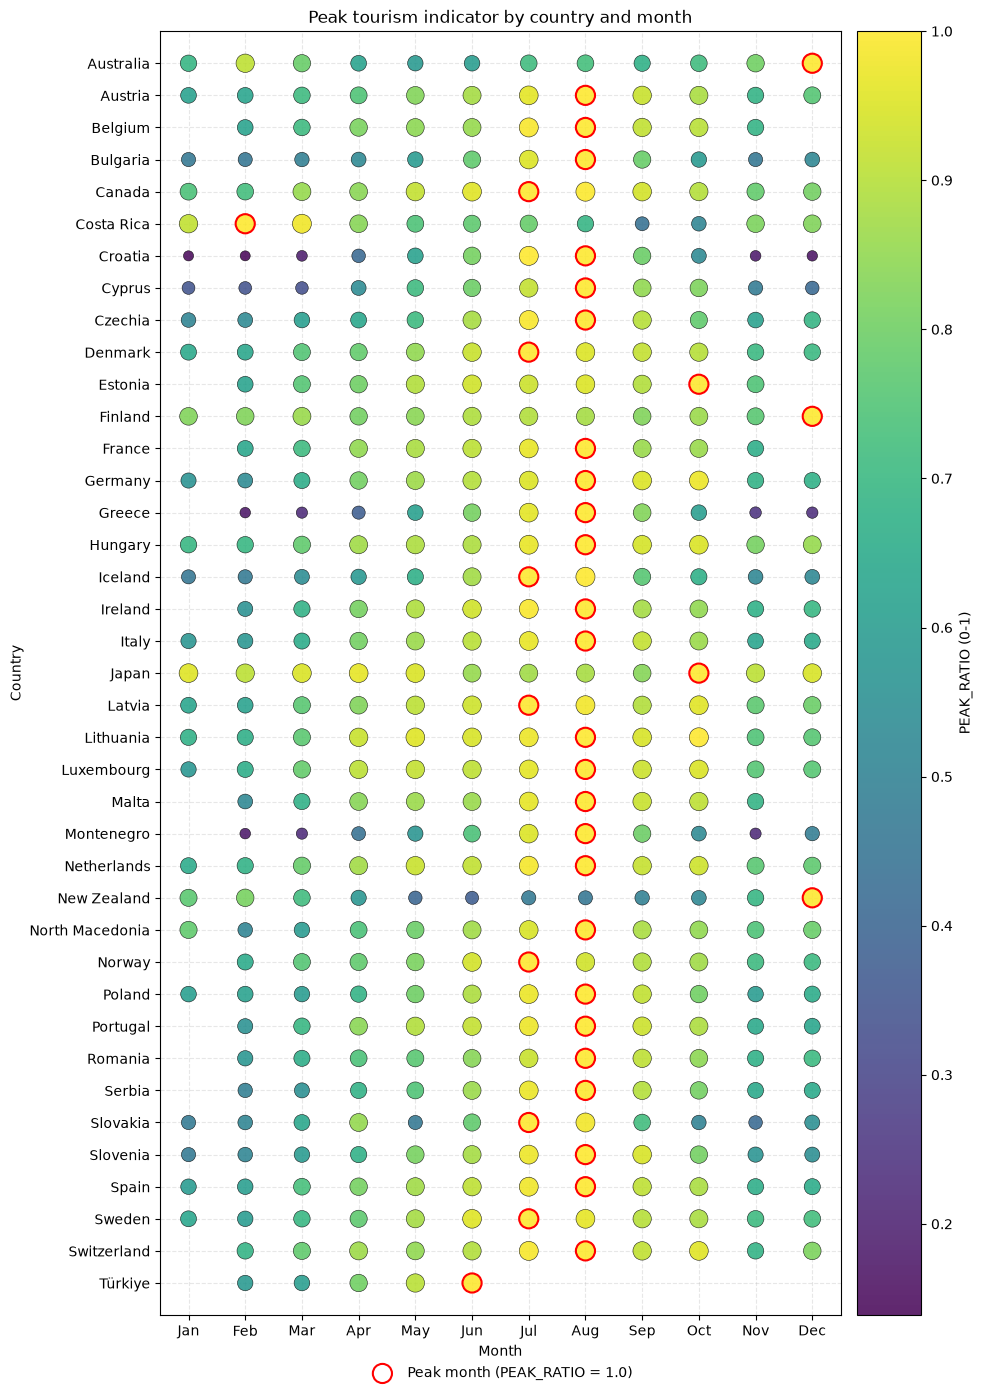

In [6]:
fig, ax = plt.subplots(figsize=(10, 14))

scatter = ax.scatter(
    peak_tourism["MONTH"],
    peak_tourism["y"],
    c=peak_tourism["PEAK_RATIO"],
    s=peak_tourism["PEAK_RATIO"] * 160 + 30,
    cmap="viridis",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.4,
    zorder=2,
)

# Outline each country's actual peak month (PEAK_RATIO == 1.0) in red so
# the peak-season pattern reads clearly against the rest of the year.
peak_months = peak_tourism[peak_tourism["PEAK_RATIO"] == 1.0]
ax.scatter(
    peak_months["MONTH"],
    peak_months["y"],
    facecolors="none",
    edgecolors="red",
    linewidths=1.5,
    s=190,
    zorder=3,
    label="Peak month (PEAK_RATIO = 1.0)",
)

ax.set_yticks(range(len(countries_bottom_to_top)))
ax.set_yticklabels(countries_bottom_to_top)
ax.set_ylim(-1, len(countries_bottom_to_top))

ax.set_xticks(range(1, 13))
ax.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
ax.set_xlim(0.5, 12.5)

ax.set_xlabel("Month")
ax.set_ylabel("Country")
ax.set_title("Peak tourism indicator by country and month")
ax.grid(axis="both", linestyle="--", alpha=0.3, zorder=1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.03), frameon=False)

cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label("PEAK_RATIO (0-1)")

plt.tight_layout()
plt.show()